# Milestone 3 – Geographical Analysis of US Disaster Declarations

This milestone analyzes the geographical distribution of natural disaster declarations across the United States.  
The objective is to identify disaster hotspots and visualize disaster patterns across different states.

1. Import libraries and load the cleaned dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv("usnd_cleaned.csv")
df.head()

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,fips,place_code,designated_area,declaration_request_number,incident_id,region,last_refresh,hash,id,year
0,DR-1-GA,1,GA,DR,1953-05-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,13000,0,Statewide,53013,53013,4,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2,1953
1,DR-2-TX,2,TX,DR,1953-05-15 00:00:00+00:00,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,48000,0,Statewide,53003,53003,6,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8,1953
2,DR-3-LA,3,LA,DR,1953-05-29 00:00:00+00:00,1953,Flood,Flood,0,1,...,22000,0,Statewide,53005,53005,6,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265,1953
3,DR-4-MI,4,MI,DR,1953-06-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,26000,0,Statewide,53004,53004,5,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6,1953
4,DR-5-MT,5,MT,DR,1953-06-06 00:00:00+00:00,1953,Flood,Floods,0,1,...,30000,0,Statewide,53006,53006,8,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4,1953


In [3]:
df.shape

(68485, 24)

In [4]:
df.isnull().sum()

fema_declaration_string       0
disaster_number               0
state                         0
declaration_type              0
declaration_date              0
fy_declared                   0
incident_type                 0
declaration_title             0
ih_program_declared           0
ia_program_declared           0
pa_program_declared           0
hm_program_declared           0
incident_begin_date           0
tribal_request                0
fips                          0
place_code                    0
designated_area               0
declaration_request_number    0
incident_id                   0
region                        0
last_refresh                  0
hash                          0
id                            0
year                          0
dtype: int64

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Verify required columns

In [13]:
df.rename(columns={'incident_type':'incidentType'}, inplace=True)

df['declaration_date'] = pd.to_datetime(df['declaration_date'])

df['year'] = df['declaration_date'].dt.year
df['month'] = df['declaration_date'].dt.month

In [15]:
df.to_csv("usnd_cleaned.csv", index=False)
df

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incidentType,declaration_title,ih_program_declared,ia_program_declared,...,place_code,designated_area,declaration_request_number,incident_id,region,last_refresh,hash,id,year,month
0,DR-1-GA,1,GA,DR,1953-05-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,0,Statewide,53013,53013,4,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2,1953,5
1,DR-2-TX,2,TX,DR,1953-05-15 00:00:00+00:00,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,0,Statewide,53003,53003,6,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8,1953,5
2,DR-3-LA,3,LA,DR,1953-05-29 00:00:00+00:00,1953,Flood,Flood,0,1,...,0,Statewide,53005,53005,6,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265,1953,5
3,DR-4-MI,4,MI,DR,1953-06-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,0,Statewide,53004,53004,5,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6,1953,6
4,DR-5-MT,5,MT,DR,1953-06-06 00:00:00+00:00,1953,Flood,Floods,0,1,...,0,Statewide,53006,53006,8,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4,1953,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68480,DR-4892-WI,4892,WI,DR,2025-09-11 00:00:00+00:00,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,99131,Washington (County),25120,2025081401,5,2025-09-12T12:21:22Z,22cc4f080a3606258847520b92c4b060e755169d,e411afd4-9728-4e8f-92d7-5297a68d9d61,2025,9
68481,DR-4892-WI,4892,WI,DR,2025-09-11 00:00:00+00:00,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,99133,Waukesha (County),25120,2025081401,5,2025-09-12T12:21:22Z,4c1feec709c248d71d6050b7bd00ae161713cec8,78bf5f2e-2a45-4a62-9bfd-0730cd793ad8,2025,9
68482,DR-4890-SD,4890,SD,DR,2025-09-11 00:00:00+00:00,2025,Flood,Severe Storm And Flooding,1,0,...,35640,Lake Traverse (Sisseton) Indian Reservation,25107,2025061301,8,2025-10-06T11:21:18Z,6dfd564e2f139f811d57ce6356ae71efc8a4def8,8d4df2f8-c769-4cc6-8f6e-ea5f7204cca6,2025,9
68483,FM-5613-HI,5613,HI,FM,2025-09-23 00:00:00+00:00,2025,Fire,Holomua Fire,0,0,...,99009,Maui (County),25127,2025092401,9,2025-10-02T18:41:08Z,2042dbeff97bbd2e761d43150e2ee99fd1634712,f8264c5d-08ce-4a9d-be33-6f78ad4fd6a9,2025,9


In [16]:
df[['state','incidentType','year','month']].head()

,state,incidentType,year,month
0,GA,Tornado,1953,5
1,TX,Tornado,1953,5
2,LA,Flood,1953,5
3,MI,Tornado,1953,6
4,MT,Flood,1953,6


State-level Aggregation

In [17]:
state_counts = df.groupby('state').size().reset_index(name='disaster_count')

state_counts.sort_values(by='disaster_count', ascending=False).head()

,state,disaster_count
50,TX,5386
20,KY,3235
28,MO,2829
10,FL,2791
12,GA,2653


State + Incident Type Aggregation

In [18]:
state_incident = df.groupby(['state','incidentType']).size().reset_index(name='count')

state_incident.head()

,state,incidentType,count
0,AK,Biological,121
1,AK,Coastal Storm,2
2,AK,Earthquake,13
3,AK,Fire,35
4,AK,Flood,61


Top10 Disaster States (Bar chat)

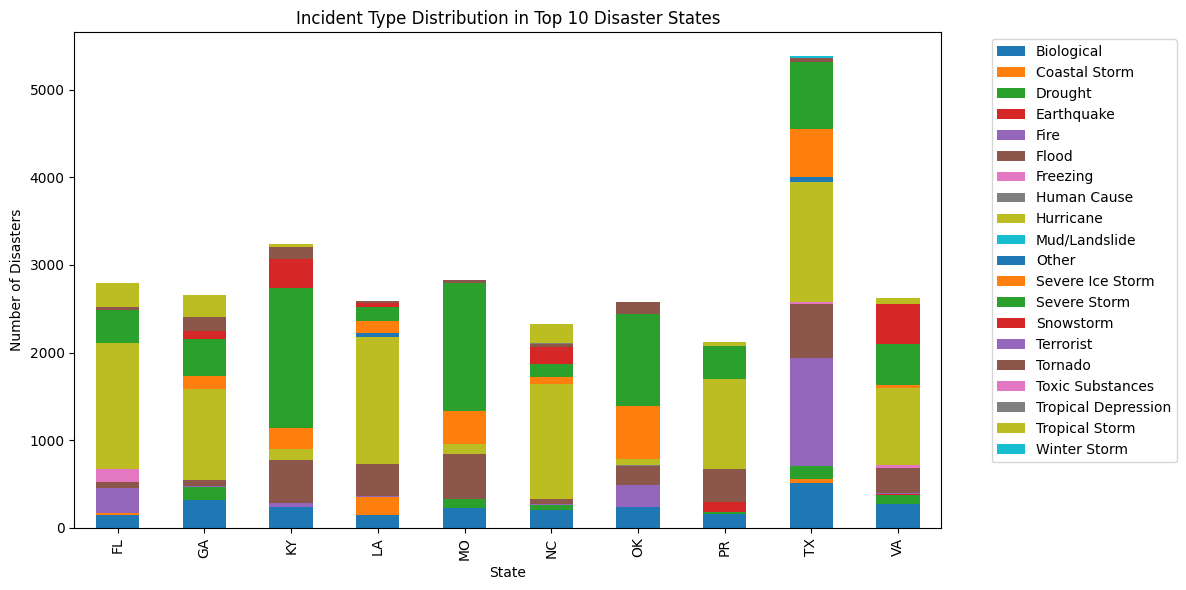

In [37]:
# Get top 10 states
top_states = df['state'].value_counts().head(10).index

 
filtered_df = df[df['state'].isin(top_states)]

 
state_incident = filtered_df.groupby(['state','incidentType']).size().reset_index(name='count')

 
pivot_data = state_incident.pivot(index='state', columns='incidentType', values='count').fillna(0)

 
pivot_data.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title("Incident Type Distribution in Top 10 Disaster States")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()

Choropleth Map (Main Visualization)

In [36]:
fig = px.choropleth(
    state_counts,
    locations='state',
    locationmode="USA-states",
    color='disaster_count',
    scope="usa",
    color_continuous_scale="Oranges",
    title="US Disaster Declarations by State"
)

fig.show()

Disaster Type Hotspot Map

In [21]:
hurricane_data = df[df['incidentType']=="Hurricane"]

hurricane_counts = hurricane_data.groupby('state').size().reset_index(name='count')

fig = px.choropleth(
    hurricane_counts,
    locations='state',
    locationmode="USA-states",
    color='count',
    scope="usa",
    title="Hurricane Disaster Hotspots"
)

fig.show()

Milestone-3 analysis shows that disaster declarations are not evenly distributed across the United States.

Certain states such as Texas, California, and Florida experience significantly more disasters due to their geographical and climatic conditions.

The visualizations help identify disaster hotspots and dominant disaster types, which can assist in disaster preparedness and policy planning